In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler , FunctionTransformer , OrdinalEncoder , OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score , RandomizedSearchCV
from scipy.stats import uniform
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost                 import XGBClassifier


In [2]:
spaceship = pd.read_csv("F://Spaceship_Titanic//Data//train (3).csv")

In [3]:
spaceship_df = spaceship.copy()

In [65]:
spaceship_df.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [66]:
spaceship_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [67]:
spaceship_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [68]:
import sweetviz as sv

In [ ]:
report = sv.analyze(spaceship_df)
report.show_html("F://Spaceship_Titanic//Reports//raw_report.html" , open_browser=False)

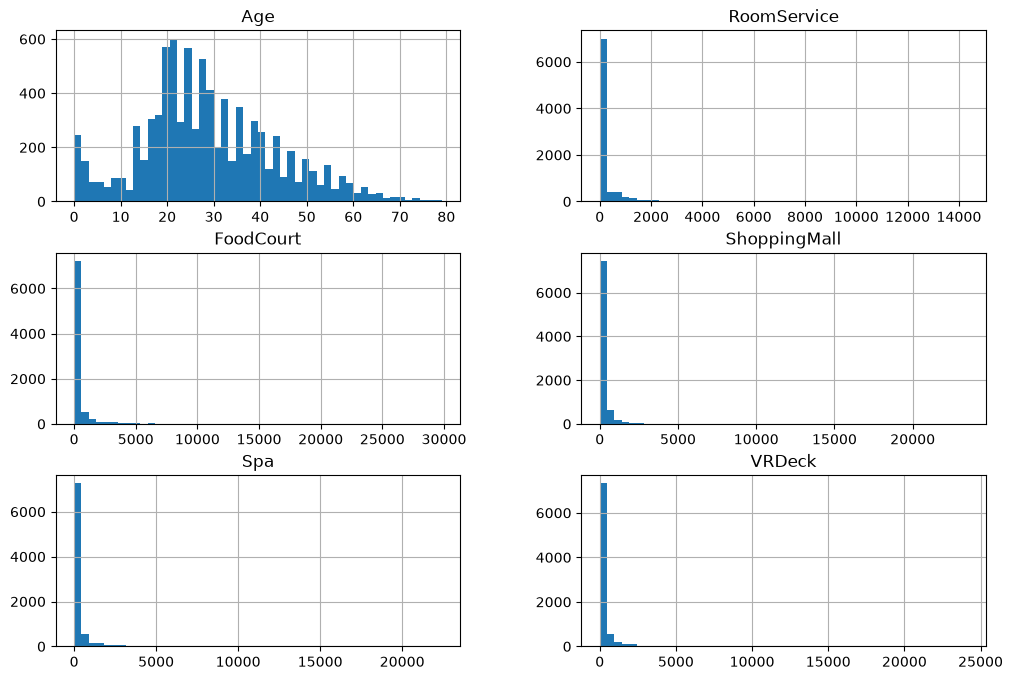

In [40]:
spaceship_df.hist(bins=50 , figsize=(12 ,8))
plt.show()

In [91]:
X_temp = spaceship_df.copy()

In [92]:
corr_matrix = spaceship_df.corr(numeric_only=True)

In [93]:
corr_matrix["Transported"].sort_values(ascending=False)

Transported     1.000000
FoodCourt       0.046566
ShoppingMall    0.010141
Age            -0.075026
VRDeck         -0.207075
Spa            -0.221131
RoomService    -0.244611
Name: Transported, dtype: float64

In [94]:
X_temp["VIP"] = X_temp["VIP"].fillna(X_temp["VIP"].mode()[0])

In [95]:
X_temp["VIP_Numeric"] = X_temp.VIP.astype(int)

In [96]:
X_temp["CryoSleep"] = X_temp["CryoSleep"].fillna(X_temp["CryoSleep"].mode()[0])

In [97]:
X_temp["CryoSleep_Numeric"] = X_temp.CryoSleep.astype(int)

In [98]:
X_temp["Age_bracket"] = pd.cut(X_temp['Age'], bins=[-np.inf, 12, 18, 60, np.inf], labels=['child','teen','adult','senior'])

In [99]:
X_temp["Total_spend"] = X_temp[["RoomService" , "FoodCourt" , "ShoppingMall" , "Spa" , "VRDeck"]].sum(axis=1)

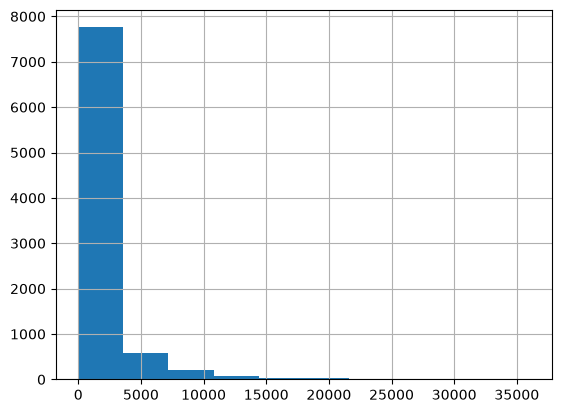

In [78]:
X_temp["Total_spend"].hist()
plt.show()

In [100]:
X_temp["Spending_bracket"] = "No_spend"
mask = X_temp["Total_spend"] > 0
X_temp.loc[mask, "Spending_bracket"] = pd.qcut(
    X_temp.loc[mask, "Total_spend"], q=2, labels=["Low_spender", "High_spender"]
)

In [101]:
X_temp["Group"] = X_temp["PassengerId"].str.split("_").str[0]

In [102]:
group_counts = X_temp["Group"].value_counts()

In [103]:
X_temp["Group_size"] = X_temp["Group"].map(group_counts)

In [104]:
X_temp["Is_alone"] = (X_temp["Group_size"] == 1).map({True: 1 , False: 0})

In [105]:
X_temp['Deck'] = X_temp['Cabin'].str.split('/').str[0]

In [106]:
X_temp.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Transported,VIP_Numeric,CryoSleep_Numeric,Age_bracket,Total_spend,Spending_bracket,Group,Group_size,Is_alone,Deck
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,False,0,0,adult,0.0,No_spend,0001,1,1,B
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,True,0,0,adult,736.0,Low_spender,0002,1,1,F
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,False,1,0,adult,10383.0,High_spender,0003,2,0,A
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,False,0,0,adult,5176.0,High_spender,0003,2,0,A
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,True,0,0,teen,1091.0,Low_spender,0004,1,1,F


In [107]:
X_temp["Starboard_side"] = np.where(
    X_temp["Cabin"].str.split("/").str[2] == "S",
    1,
    0
)

In [108]:
new_corr = X_temp.corr(numeric_only=True)

In [109]:
new_corr["Transported"].sort_values(ascending=False)

Transported          1.000000
CryoSleep_Numeric    0.460132
Starboard_side       0.101455
Group_size           0.082644
FoodCourt            0.046566
ShoppingMall         0.010141
VIP_Numeric         -0.037261
Age                 -0.075026
Is_alone            -0.113792
Total_spend         -0.199514
VRDeck              -0.207075
Spa                 -0.221131
RoomService         -0.244611
Name: Transported, dtype: float64

In [110]:
X_temp.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VIP_Numeric,CryoSleep_Numeric,Age_bracket,Total_spend,Spending_bracket,Group,Group_size,Is_alone,Deck,Starboard_side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0,0,adult,0.0,No_spend,0001,1,1,B,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,0,0,adult,736.0,Low_spender,0002,1,1,F,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,1,0,adult,10383.0,High_spender,0003,2,0,A,1
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,0,0,adult,5176.0,High_spender,0003,2,0,A,1
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,0,0,teen,1091.0,Low_spender,0004,1,1,F,1


In [111]:
X_temp.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'VIP_Numeric', 'CryoSleep_Numeric',
       'Age_bracket', 'Total_spend', 'Spending_bracket', 'Group', 'Group_size',
       'Is_alone', 'Deck', 'Starboard_side'],
      dtype='str')

In [112]:
X_temp = X_temp.drop(columns=["PassengerId" , "CryoSleep" , "Cabin" , "VIP" , "RoomService" , "FoodCourt" , "ShoppingMall" , "Spa" , "VRDeck" , "Name"])

In [113]:
X_temp.head()

,HomePlanet,Destination,Age,Transported,VIP_Numeric,CryoSleep_Numeric,Age_bracket,Total_spend,Spending_bracket,Group,Group_size,Is_alone,Deck,Starboard_side
0,Europa,TRAPPIST-1e,39.0,False,0,0,adult,0.0,No_spend,0001,1,1,B,0
1,Earth,TRAPPIST-1e,24.0,True,0,0,adult,736.0,Low_spender,0002,1,1,F,1
2,Europa,TRAPPIST-1e,58.0,False,1,0,adult,10383.0,High_spender,0003,2,0,A,1
3,Europa,TRAPPIST-1e,33.0,False,0,0,adult,5176.0,High_spender,0003,2,0,A,1
4,Earth,TRAPPIST-1e,16.0,True,0,0,teen,1091.0,Low_spender,0004,1,1,F,1


In [25]:
def transform(df):
    X = df.copy()
    X["VIP"] = X["VIP"].fillna(X["VIP"].mode()[0])
    X["HomePlanet"] = X["HomePlanet"].fillna(X["HomePlanet"].mode()[0])
    X["Destination"] = X["Destination"].fillna(X["Destination"].mode()[0])
    X["Age"] = X["Age"].fillna(X["Age"].median())
    X["VIP_Numeric"] = X.VIP.astype(int)
    X["Age_bracket"] = pd.cut(X['Age'], bins=[-np.inf, 12, 18, 60, np.inf], labels=['child','teen','adult','senior'])
    X["Total_spend"] = X[["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]].sum(axis=1)
    X["CryoSleep"] = X["CryoSleep"].where(X["CryoSleep"].notna(), X["Total_spend"] == 0)
    X["CryoSleep_Numeric"] = X.CryoSleep.astype(int)  
    X["Spending_bracket"] = "No_spend"
    mask = X["Total_spend"] > 0
    X.loc[mask, "Spending_bracket"] = pd.qcut(X.loc[mask, "Total_spend"], q=2, labels=["Low_spender", "High_spender"])
    X["Group"] = X["PassengerId"].str.split("_").str[0]
    group_counts = X["Group"].value_counts()
    X["Group_size"] = X["Group"].map(group_counts)
    X["Is_alone"] = (X["Group_size"] == 1).map({True: 1, False: 0})
    X['Deck'] = X['Cabin'].str.split('/').str[0]
    X["Deck"] = X["Deck"].fillna(X["Deck"].mode()[0])
    X["Starboard_side"] = np.where(X["Cabin"].str.split("/").str[2] == "S", 1, 0)
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    X[spend_cols] = X[spend_cols].fillna(0)
    X = X.drop(columns=["PassengerId", "CryoSleep", "Cabin", "VIP", "Name"])
    return X

In [26]:
numeric_coloumns = ["Age" , "VIP_Numeric" , "CryoSleep_Numeric" , "Total_spend" , "Group_size" , "Is_alone" , "Starboard_side" , "RoomService" , "FoodCourt" , "ShoppingMall" , "Spa" , "VRDeck" ]
categorical_coloumns_one_hot = ["HomePlanet" , "Destination" , "Deck"]
categorical_coloumns_ordinal = [ "Age_bracket" , "Spending_bracket"]

In [27]:
numeric_pipeline = Pipeline(
    [
        ("Scaler" , StandardScaler()),
    ]
)

In [28]:
categorical_ohe_pipeline = Pipeline(
    [
        ("Encoder" , OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [29]:
categorical_ord_pipeline = Pipeline(
    [
        ("Encoder" , OrdinalEncoder(
            categories=[
                ['child','teen','adult','senior'],
                ["No_spend" , "Low_spender", "High_spender"]
            ]
        ))
    ]
)

In [30]:
preprocessor = ColumnTransformer(
    [
        ("num" , numeric_pipeline , numeric_coloumns),
        ("categorical_ohe" , categorical_ohe_pipeline , categorical_coloumns_one_hot),
        ("categorical_ord" , categorical_ord_pipeline , categorical_coloumns_ordinal)

    ]
)

In [37]:
logistic_pipeline = Pipeline(
    [
        ("Feature_engineering" , FunctionTransformer(transform)),
        ("Preprocessing" , preprocessor),
        ("model" , LogisticRegression(C=1.93 , max_iter=1000))
    ]
)

In [38]:
X = spaceship_df.drop(columns = ["Transported"])
y = spaceship_df["Transported"]

In [39]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.30 , random_state=42)

In [40]:
scores = cross_val_score(logistic_pipeline ,X_train , y_train , cv = 5 , scoring="accuracy" )

In [41]:
scores

array([0.78800329, 0.79457683, 0.79457683, 0.78800329, 0.81265407])

In [35]:
param_dist = {
    "model__C" : uniform(0.1 , 10)
}

random_search_logistic = RandomizedSearchCV(
    logistic_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv = 5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

In [36]:
random_search_logistic.fit(X_train , y_train)
print(random_search_logistic.best_params_)
print(random_search_logistic.best_score_)

{'model__C': np.float64(1.9340450985343383)}
0.7955628594905505


In [42]:
logistic_pipeline.fit(X_train , y_train)
final_score = logistic_pipeline.score(X_test , y_test)
final_score

0.7822085889570553

In [48]:
Tree_pipeline = Pipeline(
    [
        ("Feature_engineering" , FunctionTransformer(transform)),
        ("Preprocessing" , preprocessor),
        ("model" , DecisionTreeClassifier(min_samples_split = 10, min_samples_leaf = 20, max_depth = 10, criterion = 'entropy' , random_state=42))
    ]
)

In [49]:
scores = cross_val_score(Tree_pipeline ,X_train , y_train , cv = 5 , scoring="accuracy" )
scores

array([0.77321282, 0.79539852, 0.78142975, 0.79129006, 0.78718159])

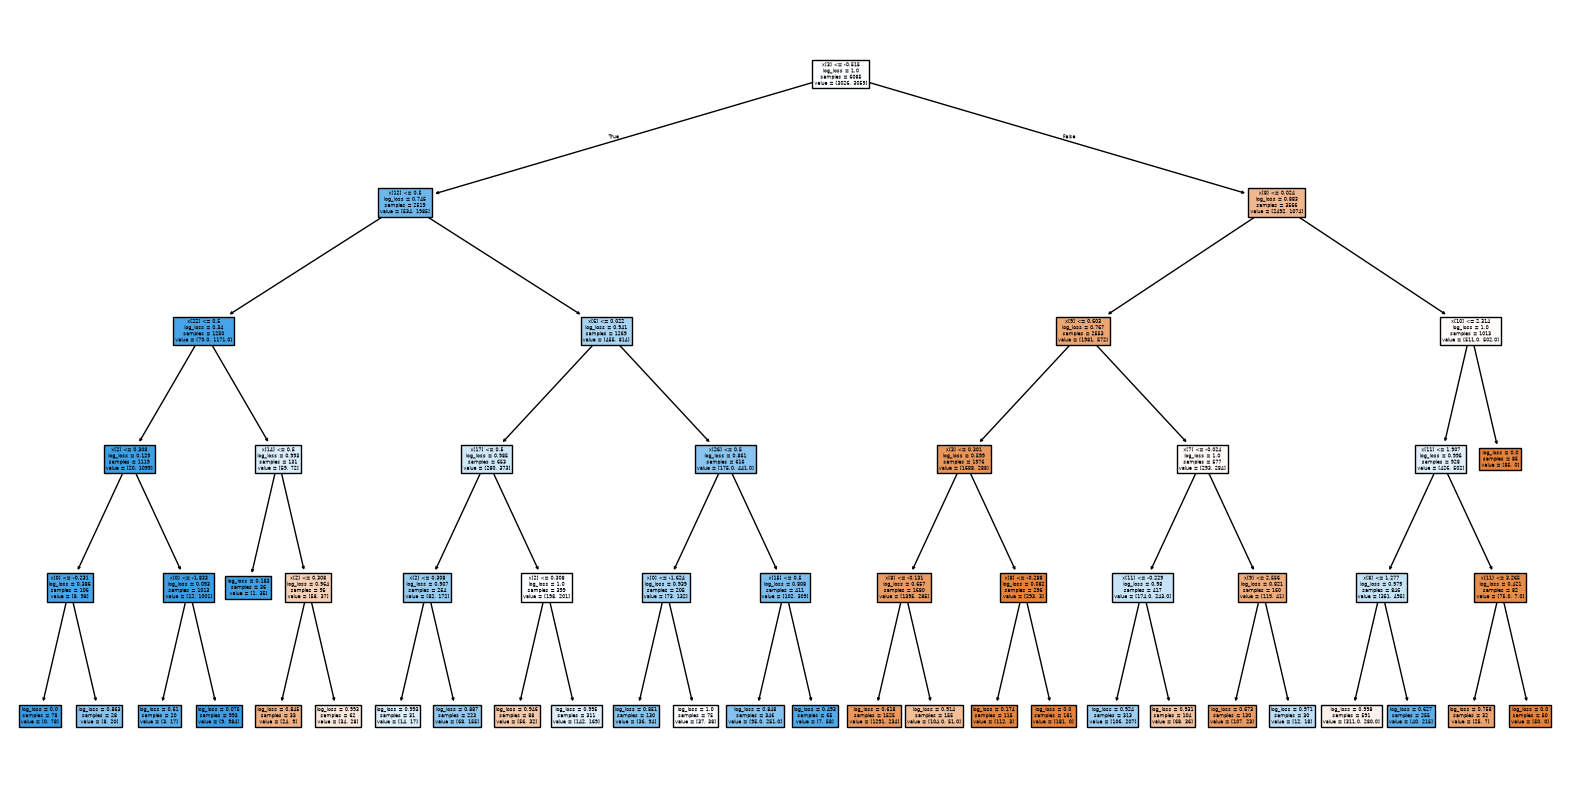

In [45]:
plt.figure(figsize=(20, 10))
Tree_pipeline.fit(X_train , y_train)
plot_tree(Tree_pipeline.named_steps["model"], filled=True)
plt.show()

In [46]:
param_dist = {
    "model__max_depth": [3, 5, 10, 15, 20, 50],
    "model__criterion": ["entropy", "gini", "log_loss"],
    "model__min_samples_split": [2, 5, 10, 15, 20, 50],
    "model__min_samples_leaf": [1, 2, 5, 10, 20]
}


In [47]:
random_tree_search = RandomizedSearchCV(
    Tree_pipeline,
    param_distributions=param_dist,
    n_iter=20,             
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1              
)

random_tree_search.fit(X_train, y_train)
print(random_tree_search.best_params_)
print(random_tree_search.best_score_)

{'model__min_samples_split': 10, 'model__min_samples_leaf': 20, 'model__max_depth': 10, 'model__criterion': 'entropy'}
0.7857025472473296


In [50]:
Tree_pipeline.fit(X_train , y_train)
final_score = Tree_pipeline.score(X_test , y_test)
final_score

0.776457055214724

In [55]:
forest_pipeline = Pipeline(
    [
        ("Feature_engineering" , FunctionTransformer(transform)),
        ("Preprocessing" , preprocessor),
        ("model" , RandomForestClassifier(n_estimators = 50, min_samples_split = 20, min_samples_leaf = 5, max_features = 'log2', max_depth = None, criterion = 'log_loss', random_state=42))
]
)

In [56]:
scores = cross_val_score(forest_pipeline ,X_train , y_train , cv = 5 , scoring="accuracy" )
scores

array([0.7978636 , 0.81265407, 0.79457683, 0.80608053, 0.81183237])

In [53]:
param_dist = {
    "model__n_estimators" : [50,100,200,300,400,500],
    "model__max_depth": [3, 5, 10, 15, 20, 50 , None],
    "model__max_features": ["sqrt" , "log2"],
    "model__min_samples_split": [2, 5, 10, 15, 20, 50],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__criterion": ["entropy", "gini", "log_loss"],
}

random_forest_search = RandomizedSearchCV(
    forest_pipeline,
    param_distributions=param_dist,
    n_iter=20,             
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1              
)

random_forest_search.fit(X_train, y_train)
print(random_forest_search.best_params_)
print(random_forest_search.best_score_)

{'model__n_estimators': 50, 'model__min_samples_split': 20, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': None, 'model__criterion': 'log_loss'}
0.8046014790468364


In [57]:
forest_pipeline.fit(X_train , y_train)
final_score = forest_pipeline.score(X_test , y_test)
final_score

0.7887269938650306

In [66]:
boosted_forest_pipeline = Pipeline(
    [
        ("Feature_engineering" , FunctionTransformer(transform)),
        ("Preprocessing" , preprocessor),
        ("Model" , XGBClassifier(subsample = 0.8, n_estimators = 150, min_child_weight = 7, max_depth = 5, learning_rate = 0.1, gamma = 0.5, colsample_bytree = 0.6
))
    ]
)

In [63]:
score_boosted_tree = cross_val_score(boosted_forest_pipeline , X_train , y_train , cv=5)
score_boosted_tree

array([0.79622021, 0.8085456 , 0.8085456 , 0.80608053, 0.81429745])

In [60]:
param_dist = {
    "Model__n_estimators": [100, 150, 200],
    "Model__max_depth": [2, 3, 4, 5],       
    "Model__learning_rate": [0.01, 0.05, 0.1],
    "Model__subsample": [0.6, 0.7, 0.8],
    "Model__colsample_bytree": [0.6, 0.7, 0.8],
    "Model__gamma": [0.5, 1, 2, 5],           
    "Model__min_child_weight": [5, 7, 10, 15] 
}


In [65]:
random_boosted_search = RandomizedSearchCV(
    boosted_forest_pipeline,
    param_distributions=param_dist,
    n_iter=75,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_boosted_search.fit(X_train, y_train)
print(random_boosted_search.best_params_)
print(random_boosted_search.best_score_)

{'Model__subsample': 0.8, 'Model__n_estimators': 150, 'Model__min_child_weight': 7, 'Model__max_depth': 5, 'Model__learning_rate': 0.1, 'Model__gamma': 0.5, 'Model__colsample_bytree': 0.6}
0.8075595727198028


In [67]:
boosted_forest_pipeline.fit(X_train , y_train)
final_score = boosted_forest_pipeline.score(X_test , y_test)
final_score

0.7948619631901841

In [70]:
boosted_forest_pipeline = Pipeline(
    [
        ("Feature_engineering" , FunctionTransformer(transform)),
        ("Preprocessing" , preprocessor),
        ("Model" , XGBClassifier(subsample = 0.8, n_estimators = 150, min_child_weight = 7, max_depth = 5, learning_rate = 0.1, gamma = 0.5, colsample_bytree = 0.6
))
    ]
)

In [71]:
score_boosted_tree = cross_val_score(boosted_forest_pipeline , X , y , cv=5)
score_boosted_tree

array([0.78378378, 0.786659  , 0.80966072, 0.81242808, 0.80379747])

In [ ]:
random_boosted_search = RandomizedSearchCV(
    boosted_forest_pipeline,
    param_distributions=param_dist,
    n_iter=75,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_boosted_search.fit(X, y)
print(random_boosted_search.best_params_)
print(random_boosted_search.best_score_)

In [69]:
testing_df = pd.read_csv("F://Spaceship_Titanic//Data//test (3).csv")
passenger_ids = testing_df["PassengerId"]

final_predict = random_boosted_search.predict(testing_df)

submission = pd.DataFrame({
    "PassengerId" : passenger_ids,
    "Transported": final_predict.astype(bool)
})

submission.to_csv("F://Spaceship_Titanic//final_prediction.csv" , index=False)